# 03_EDA：YouTube動画メタデータの探索的データ分析

このnotebookでは、前工程で作成した `data/processed/videos_labeled.csv` を使って、分類モデルを作る前にデータの特徴を確認する。

今回のEDAの目的は、単にグラフを作ることではなく、以下を確認することである。

* 学習データの件数とクラスバランス
* タイトル・概要欄・結合テキストの長さ
* 概要欄に含まれるURL・ドメインの傾向
* 概要欄に含まれるハッシュタグの傾向
* どのジャンルにも共通して出る定型的な情報
* 特定ジャンルに偏って出る分類に有用そうな情報
* チャンネル単位の偏り
* TF-IDF + ロジスティック回帰に進む前に注意すべき点

特に、URL・ドメイン・ハッシュタグは最初から単純にノイズとは決めつけない。

ジャンル分類に役立つものもあれば、どのジャンルにも共通して出る定型文のようなものもある。

そのため、このEDAでは以下のように分けて考える。

* 多くのジャンルに共通して出るハッシュタグ・ドメイン: 削除候補
* 特定ジャンルに偏って出るハッシュタグ・ドメイン: 分類に有用な特徴候補

まずはデータの傾向を確認し、その後の前処理や分類実験につなげる。


## 1. ライブラリ読み込み・パス設定

まず、EDAで使うライブラリを読み込み、プロジェクト内のファイルパスを設定する。

このnotebookでは、主に以下を使う。

* `pandas`: CSVの読み込み、集計、表形式データの確認
* `matplotlib`: 必要に応じたグラフ作成
* `pathlib.Path`: OSに依存しにくいファイルパスの扱い
* `re`: URLやハッシュタグを正規表現で抽出するために使う
* `urllib.parse`: URLからドメインを取り出すために使う

`PROJECT_ROOT` はプロジェクトのルートディレクトリを表す変数として使う。

In [ ]:
from pathlib import Path
import re
from urllib.parse import urlparse

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "videos_labeled.csv"
OUTPUTS_DIR = PROJECT_ROOT / "data" / "analysis" / "eda"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUTS_DIR:", OUTPUTS_DIR)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)

PROJECT_ROOT: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc
DATA_PATH: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/processed/videos_labeled.csv


## 2. processed CSVの読み込み

前工程で作成した `data/processed/videos_labeled.csv` を読み込む。

このCSVには、学習対象となる4ジャンルの動画データが入っている。

対象ジャンルは以下である。

* music
* game
* study
* cooking

1行が1本のYouTube動画に対応している。

In [78]:
if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("shape:", df.shape)
display(df.head())

shape: (443, 24)


,video_id,url,genre,title,description,channel_id,channel_title,tags,category_id,duration,...,default_language,default_audio_language,fetched_at,text_base,text_title_weight_1,text_title_weight_2,text_title_weight_3,title_length,description_length,text_length
0,ktzbPzmAnnw,https://www.youtube.com/watch?v=ktzbPzmAnnw,music,「胎児の夢」 feat.初音ミク,"胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Movie, illustration：水都\n\n※動画に記載されているのは旧名です。\n\n【off ...",UCVJns279mOOd92lWVQl_HlA,水都,"[""#VOCALOID"", ""#初音ミク""]",10,PT3M33S,...,ja,NaN,2026-06-20T13:05:06.655004+00:00,"「胎児の夢」 feat.初音ミク 胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Movie, illustration：水都\n\n※動画に記載されてい...","「胎児の夢」 feat.初音ミク 胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Movie, illustration：水都\n\n※動画に記載されてい...","「胎児の夢」 feat.初音ミク 「胎児の夢」 feat.初音ミク 胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Movie, illustration...","「胎児の夢」 feat.初音ミク 「胎児の夢」 feat.初音ミク 「胎児の夢」 feat.初音ミク 胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Mo...",16,213,230
1,arlXG7TVdPk,https://www.youtube.com/watch?v=arlXG7TVdPk,music,天使じゃないよ/初音ミク,他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https://x.com/echize_nn?s=21&t=nbH4Oc...\n\nof...,UCF9BrkN5Z5tqAwuj_s0519g,越前,[],22,PT3M36S,...,ja,NaN,2026-06-20T13:05:06.655004+00:00,天使じゃないよ/初音ミク 他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https://x.com/echize_nn?s=21&t=nb...,天使じゃないよ/初音ミク 他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https://x.com/echize_nn?s=21&t=nb...,天使じゃないよ/初音ミク 天使じゃないよ/初音ミク 他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https://x.com/echize...,天使じゃないよ/初音ミク 天使じゃないよ/初音ミク 天使じゃないよ/初音ミク 他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https:/...,12,171,184
2,DNltbDXaKw8,https://www.youtube.com/watch?v=DNltbDXaKw8,music,きおくをみたの/初音ミク(まかろり×いのうつはSA),生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https://twitter.com/@urayahayahaurra)\n\n編曲映像：いのうつはSA\n(https://twitter.com/@nantoka_SA)...,UCB7DcMLTrdCeCENzfZIfKLQ,まかろり,[],22,PT3M45S,...,ja,ja,2026-06-20T13:05:06.655004+00:00,きおくをみたの/初音ミク(まかろり×いのうつはSA) 生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https://twitter.com/@urayahayahaurra)\n\n編曲映像：いのうつはSA\n(https...,きおくをみたの/初音ミク(まかろり×いのうつはSA) 生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https://twitter.com/@urayahayahaurra)\n\n編曲映像：いのうつはSA\n(https...,きおくをみたの/初音ミク(まかろり×いのうつはSA) きおくをみたの/初音ミク(まかろり×いのうつはSA) 生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https://twitter.com/@urayahayahaur...,きおくをみたの/初音ミク(まかろり×いのうつはSA) きおくをみたの/初音ミク(まかろり×いのうつはSA) きおくをみたの/初音ミク(まかろり×いのうつはSA) 生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https:/...,26,197,224
3,JqvE2fxm80U,https://www.youtube.com/watch?v=JqvE2fxm80U,music,夢憂鬱 / 初音ミク,VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?si=b3V-OBqu6NK9qJv-\n\n\nVocal：₁₀...,UCwqj1NywsBPbd5QZvHf-yEg,ukaihi,[],22,PT3M28S,...,ja,en,2026-06-20T13:05:06.655004+00:00,夢憂鬱 / 初音ミク VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?si=b3V-OBqu6NK9qJv-\n\...,夢憂鬱 / 初音ミク VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?si=b3V-OBqu6NK9qJv-\n\...,夢憂鬱 / 初音ミク 夢憂鬱 / 初音ミク VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?si=b3V-OBqu...,夢憂鬱 / 初音ミク 夢憂鬱 / 初音ミク 夢憂鬱 / 初音ミク VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?...,10,309,320
4,Pmj5CGPaUQ8,https://www.youtube.com/watch?v=Pmj5CGPaUQ8,music,"八月、僕らの犯した間違いの答え合わせ/ カゼヒキ - August, the answer to the mistakes we made",▶Music れーしあ\nhttps://x.com/Re_siadesu\n\n▶Illustration 肥料\nhttps://x.com/fertilizerrrr_\n\n▶Movie 肥料 れーしあ\n\n▶Mast...,UC90a5GK8XetNIlNF0kPj7yA,れーしあ / Re_shia,"[""八月"", ""僕らの犯した間違いの答え合わせ"", ""ボカロ"", ""夏 ボカロ"", ""カゼヒキ"", ""れーしあ"", ""切ないボカロ"", ""UTAU""]",10,PT3M44S,...,ja,NaN,2026-06-20T13:05:06.655004+00:00,"八月、僕らの犯した間違いの答え合わせ/ カゼヒキ - August, the answer to the mistakes we made ▶Music れーしあ\nhttps://x.com/Re_siadesu\n\n▶Ill...","八月、僕らの犯した間違いの答え合わせ/ カゼヒキ 

## 3. データの基本情報を確認する

まず、読み込んだデータの基本情報を確認する。

ここでは以下を見る。

* 行数・列数
* 先頭数行
* 各列のデータ型
* 欠損値の有無
* `video_id` の重複の有無

この確認によって、EDAや機械学習に進む前に、データが想定通りの形になっているかを確認する。


In [79]:
# 先頭5行を確認する
display(df.head())
# 列名を確認する
df.columns.tolist()
df.info()

missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]

print("重複 video_id 数:", df["video_id"].duplicated().sum())

,video_id,url,genre,title,description,channel_id,channel_title,tags,category_id,duration,...,default_language,default_audio_language,fetched_at,text_base,text_title_weight_1,text_title_weight_2,text_title_weight_3,title_length,description_length,text_length
0,ktzbPzmAnnw,https://www.youtube.com/watch?v=ktzbPzmAnnw,music,「胎児の夢」 feat.初音ミク,"胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Movie, illustration：水都\n\n※動画に記載されているのは旧名です。\n\n【off ...",UCVJns279mOOd92lWVQl_HlA,水都,"[""#VOCALOID"", ""#初音ミク""]",10,PT3M33S,...,ja,NaN,2026-06-20T13:05:06.655004+00:00,"「胎児の夢」 feat.初音ミク 胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Movie, illustration：水都\n\n※動画に記載されてい...","「胎児の夢」 feat.初音ミク 胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Movie, illustration：水都\n\n※動画に記載されてい...","「胎児の夢」 feat.初音ミク 「胎児の夢」 feat.初音ミク 胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Movie, illustration...","「胎児の夢」 feat.初音ミク 「胎児の夢」 feat.初音ミク 「胎児の夢」 feat.初音ミク 胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Mo...",16,213,230
1,arlXG7TVdPk,https://www.youtube.com/watch?v=arlXG7TVdPk,music,天使じゃないよ/初音ミク,他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https://x.com/echize_nn?s=21&t=nbH4Oc...\n\nof...,UCF9BrkN5Z5tqAwuj_s0519g,越前,[],22,PT3M36S,...,ja,NaN,2026-06-20T13:05:06.655004+00:00,天使じゃないよ/初音ミク 他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https://x.com/echize_nn?s=21&t=nb...,天使じゃないよ/初音ミク 他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https://x.com/echize_nn?s=21&t=nb...,天使じゃないよ/初音ミク 天使じゃないよ/初音ミク 他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https://x.com/echize...,天使じゃないよ/初音ミク 天使じゃないよ/初音ミク 天使じゃないよ/初音ミク 他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https:/...,12,171,184
2,DNltbDXaKw8,https://www.youtube.com/watch?v=DNltbDXaKw8,music,きおくをみたの/初音ミク(まかろり×いのうつはSA),生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https://twitter.com/@urayahayahaurra)\n\n編曲映像：いのうつはSA\n(https://twitter.com/@nantoka_SA)...,UCB7DcMLTrdCeCENzfZIfKLQ,まかろり,[],22,PT3M45S,...,ja,ja,2026-06-20T13:05:06.655004+00:00,きおくをみたの/初音ミク(まかろり×いのうつはSA) 生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https://twitter.com/@urayahayahaurra)\n\n編曲映像：いのうつはSA\n(https...,きおくをみたの/初音ミク(まかろり×いのうつはSA) 生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https://twitter.com/@urayahayahaurra)\n\n編曲映像：いのうつはSA\n(https...,きおくをみたの/初音ミク(まかろり×いのうつはSA) きおくをみたの/初音ミク(まかろり×いのうつはSA) 生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https://twitter.com/@urayahayahaur...,きおくをみたの/初音ミク(まかろり×いのうつはSA) きおくをみたの/初音ミク(まかろり×いのうつはSA) きおくをみたの/初音ミク(まかろり×いのうつはSA) 生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https:/...,26,197,224
3,JqvE2fxm80U,https://www.youtube.com/watch?v=JqvE2fxm80U,music,夢憂鬱 / 初音ミク,VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?si=b3V-OBqu6NK9qJv-\n\n\nVocal：₁₀...,UCwqj1NywsBPbd5QZvHf-yEg,ukaihi,[],22,PT3M28S,...,ja,en,2026-06-20T13:05:06.655004+00:00,夢憂鬱 / 初音ミク VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?si=b3V-OBqu6NK9qJv-\n\...,夢憂鬱 / 初音ミク VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?si=b3V-OBqu6NK9qJv-\n\...,夢憂鬱 / 初音ミク 夢憂鬱 / 初音ミク VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?si=b3V-OBqu...,夢憂鬱 / 初音ミク 夢憂鬱 / 初音ミク 夢憂鬱 / 初音ミク VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?...,10,309,320
4,Pmj5CGPaUQ8,https://www.youtube.com/watch?v=Pmj5CGPaUQ8,music,"八月、僕らの犯した間違いの答え合わせ/ カゼヒキ - August, the answer to the mistakes we made",▶Music れーしあ\nhttps://x.com/Re_siadesu\n\n▶Illustration 肥料\nhttps://x.com/fertilizerrrr_\n\n▶Movie 肥料 れーしあ\n\n▶Mast...,UC90a5GK8XetNIlNF0kPj7yA,れーしあ / Re_shia,"[""八月"", ""僕らの犯した間違いの答え合わせ"", ""ボカロ"", ""夏 ボカロ"", ""カゼヒキ"", ""れーしあ"", ""切ないボカロ"", ""UTAU""]",10,PT3M44S,...,ja,NaN,2026-06-20T13:05:06.655004+00:00,"八月、僕らの犯した間違いの答え合わせ/ カゼヒキ - August, the answer to the mistakes we made ▶Music れーしあ\nhttps://x.com/Re_siadesu\n\n▶Ill...","八月、僕らの犯した間違いの答え合わせ/ カゼヒキ 

<class 'pandas.DataFrame'>
RangeIndex: 443 entries, 0 to 442
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                443 non-null    str    
 1   url                     443 non-null    str    
 2   genre                   443 non-null    str    
 3   title                   443 non-null    str    
 4   description             418 non-null    str    
 5   channel_id              443 non-null    str    
 6   channel_title           443 non-null    str    
 7   tags                    443 non-null    str    
 8   category_id             443 non-null    int64  
 9   duration                443 non-null    str    
 10  published_at            443 non-null    str    
 11  view_count              443 non-null    int64  
 12  like_count              428 non-null    float64
 13  comment_count           431 non-null    float64
 14  default_language        443 non-null    str    
 15  

In [80]:
required_columns = [
    "video_id",
    "url",
    "genre",
    "title",
    "description",
    "channel_title",
    "tags",
    "text_base",
    "title_length",
    "description_length",
    "text_length",
]

missing_required_columns = [col for col in required_columns if col not in df.columns]

if missing_required_columns:
    print("不足している列:", missing_required_columns)
else:
    print("必要な列はすべて存在します")

必要な列はすべて存在します


## 4. ジャンル別件数とクラスバランスを確認する

次に、各ジャンルに何件の動画が含まれているかを確認する。

分類モデルを作る場合、特定のジャンルだけが極端に多い、または少ないと、評価結果が偏りやすくなる。

以下のような数値でクラスバランスを確認する。

* ジャンル数
* 総件数
* 最小件数
* 最大件数
* 最大件数と最小件数の差
* 最大件数と最小件数の比
* 平均件数
* 標準偏差
* 変動係数

これにより、学習データに極端なクラス不均衡がないかを確認する。

In [81]:

genre_counts = df["genre"].value_counts()


genre_counts

genre
music      123
study      111
game       107
cooking    102
Name: count, dtype: int64

In [82]:
genre_balance = pd.DataFrame({
    "count": genre_counts,
    "ratio_percent": (genre_counts / genre_counts.sum() * 100).round(2),
})

genre_balance

,count,ratio_percent
genre,,
music,123,27.77
study,111,25.06
game,107,24.15
cooking,102,23.02


In [83]:
class_balance_summary = pd.Series({
    "n_genres": genre_counts.size,
    "total_count": genre_counts.sum(),
    "min_count": genre_counts.min(),
    "max_count": genre_counts.max(),
    "max_minus_min": genre_counts.max() - genre_counts.min(),
    "max_div_min": genre_counts.max() / genre_counts.min(),
    "mean_count": genre_counts.mean(),
    "std_count": genre_counts.std(ddof=0),
    "coefficient_of_variation": genre_counts.std(ddof=0) / genre_counts.mean(),
})

class_balance_summary.round(3)

n_genres                      4.000
total_count                 443.000
min_count                   102.000
max_count                   123.000
max_minus_min                21.000
max_div_min                   1.206
mean_count                  110.750
std_count                     7.758
coefficient_of_variation      0.070
dtype: float64

In [84]:
expected_genres = {"music", "game", "study", "cooking"}
actual_genres = set(df["genre"].unique())

print("想定ジャンル:", expected_genres)
print("実際のジャンル:", actual_genres)

if actual_genres == expected_genres:
    print("想定通りです")
else:
    print("不足:", expected_genres - actual_genres)
    print("余分:", actual_genres - expected_genres)

想定ジャンル: {'cooking', 'study', 'music', 'game'}
実際のジャンル: {'cooking', 'study', 'music', 'game'}
想定通りです


### ここまでの確認結果

processed CSVを読み込み、データの基本情報を確認した。

確認した内容は以下である。

- 行数・列数
- 主要な列の有無
- 欠損値
- `video_id` の重複
- ジャンル別件数
- クラスバランス

ジャンル別件数については、棒グラフではなく、件数・割合・最大値と最小値の差・変動係数などの数値で確認した。

この段階で大きな問題がなければ、次にタイトル・概要欄・結合テキストの文字数確認へ進む。

## 5. タイトル・概要欄・結合テキストの長さを確認する

分類に使うテキストの長さを確認する。

ここでは、以下の列を見る。

* `title_length`: タイトルの文字数
* `description_length`: 概要欄の文字数
* `text_length`: タイトルと概要欄を結合したテキストの文字数

YouTubeの概要欄には、動画内容そのものだけでなく、SNSリンク、チャンネル登録案内、商品リンク、ハッシュタグ、定型文などが含まれることがある。

そのため、タイトル、概要欄、結合テキストの文字数分布をヒストグラムで確認する。

特に概要欄は、動画によって長さの差が大きくなりやすい。

ヒストグラムを見ることで、短い概要欄が多いのか、長い概要欄が一部だけ存在するのかを確認する。

In [85]:
length_cols = ["title_length", "description_length", "text_length"]

df[length_cols].describe().round(1)

,title_length,description_length,text_length
count,443.0,443.0,443.0
mean,36.4,749.0,786.4
std,19.7,775.4,781.6
min,1.0,0.0,12.0
25%,22.0,192.5,223.5
50%,32.0,505.0,544.0
75%,47.0,1033.5,1078.0
max,98.0,4909.0,4966.0


In [86]:
df[length_cols].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]).round(1)

,title_length,description_length,text_length
0.00,1.0,0.0,12.0
0.25,22.0,192.5,223.5
0.50,32.0,505.0,544.0
0.75,47.0,1033.5,1078.0
0.90,64.8,1869.4,1915.4
0.95,75.9,2222.9,2282.8
0.99,95.0,3475.8,3535.8
1.00,98.0,4909.0,4966.0


In [87]:
length_summary = pd.DataFrame({
    "mean": df[length_cols].mean(),
    "median": df[length_cols].median(),
    "std": df[length_cols].std(),
    "min": df[length_cols].min(),
    "max": df[length_cols].max(),
})

length_summary.round(1)

,mean,median,std,min,max
title_length,36.4,32.0,19.7,1,98
description_length,749.0,505.0,775.4,0,4909
text_length,786.4,544.0,781.6,12,4966


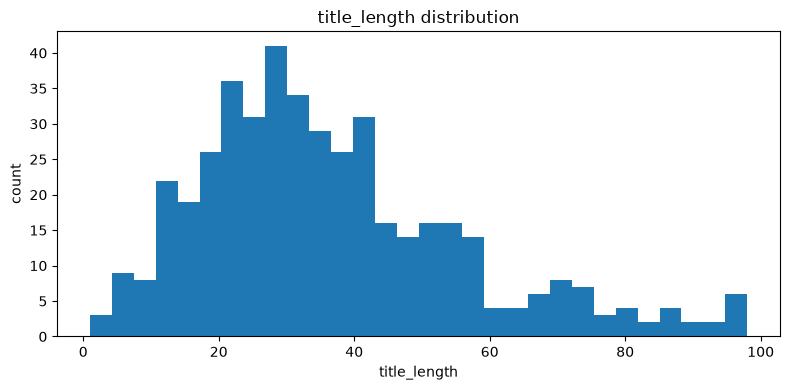

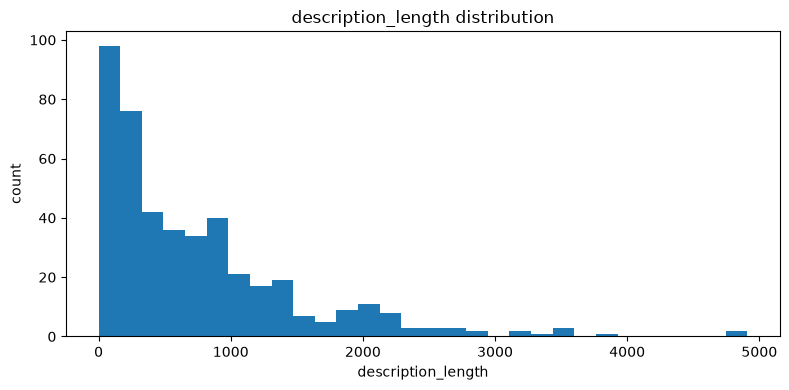

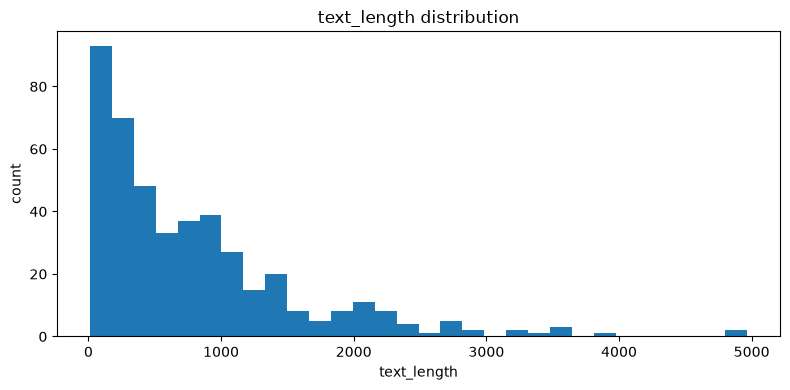

In [88]:
for col in length_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"{col} distribution")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

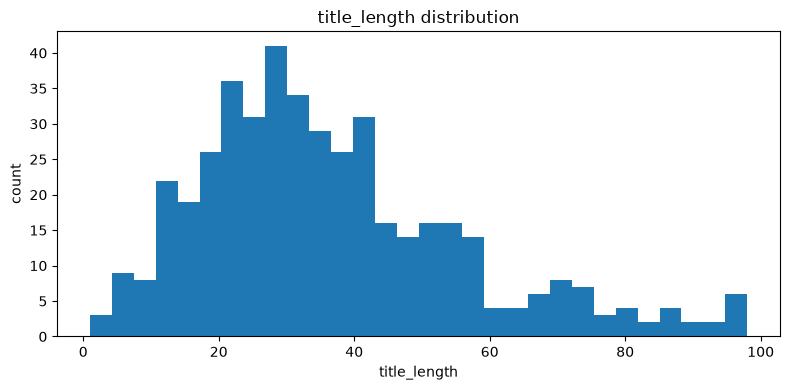

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/outputs/title_length_distribution.png


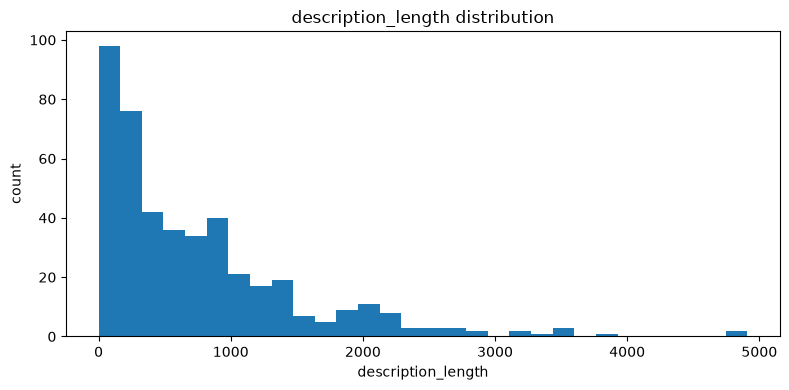

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/outputs/description_length_distribution.png


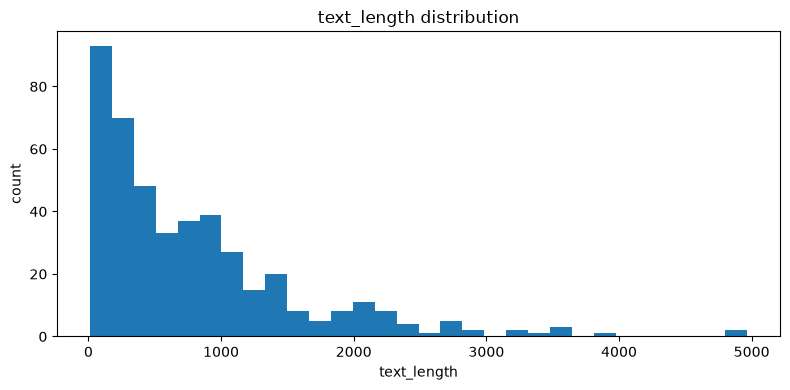

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/outputs/text_length_distribution.png


In [89]:
for col in length_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"{col} distribution")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()

    output_path = OUTPUTS_DIR / f"{col}_distribution.png"
    plt.savefig(output_path, dpi=150)
    plt.show()

    print("saved:", output_path)

## 6. ジャンルごとの文字数傾向を確認する

次に、ジャンルごとにテキストの長さに違いがあるかを確認する。

例えば、料理動画では材料や手順が概要欄に書かれていて長くなりやすい可能性がある。

音楽動画では配信リンク、歌詞、クレジット情報などが含まれる可能性がある。

学習動画では教材リンクや補足説明が含まれる可能性がある。

ゲーム動画では配信者の定型文やSNSリンクが含まれる可能性がある。

ジャンルごとの文字数の違いは、後で分類結果や誤分類例を解釈するときの参考になる。

In [90]:
genre_length_mean = df.groupby("genre")[length_cols].mean().round(1)

genre_length_mean

,title_length,description_length,text_length
genre,,,
cooking,40.8,977.6,1019.2
game,40.5,597.5,638.9
music,30.0,603.9,634.8
study,35.7,845.8,882.5


In [91]:
genre_length_median = df.groupby("genre")[length_cols].median().round(1)

genre_length_median

,title_length,description_length,text_length
genre,,,
cooking,35.0,767.5,797.5
game,36.0,523.0,575.0
music,25.0,396.0,416.0
study,32.0,513.0,552.0


In [92]:
genre_length_summary = df.groupby("genre")[length_cols].agg(
    ["mean", "median", "std", "min", "max"]
).round(1)

genre_length_summary

title_length                      description_length                \
                mean median   std min max               mean median    std   
genre                                                                        
cooking         40.8   35.0  20.0  12  98              977.6  767.5  921.0   
game            40.5   36.0  19.5   9  95              597.5  523.0  515.3   
music           30.0   25.0  18.7   1  79              603.9  396.0  637.2   
study           35.7   32.0  18.8   5  95              845.8  513.0  909.4   

                  text_length                          
        min   max        mean median    std min   max  
genre                                                  
cooking   0  3789      1019.2  797.5  927.3  12  3821  
game      0  2581       638.9  575.0  523.6  27  2669  
music     0  3213       634.8  416.0  645.2  20  3276  
study     0  4909       882.5  552.0  912.7  17  4966

In [93]:
genre_description_quantile = df.groupby("genre")["description_length"].quantile(
    [0.5, 0.75, 0.9, 0.95, 1.0]
).unstack().round(1)

genre_description_quantile

,0.50,0.75,0.90,0.95,1.00
genre,,,,,
cooking,767.5,1463.2,2211.8,2653.4,3789.0
game,523.0,870.5,1274.6,1425.2,2581.0
music,396.0,896.0,1387.8,2012.8,3213.0
study,513.0,1104.5,1919.0,2542.5,4909.0


<Figure size 800x400 with 0 Axes>

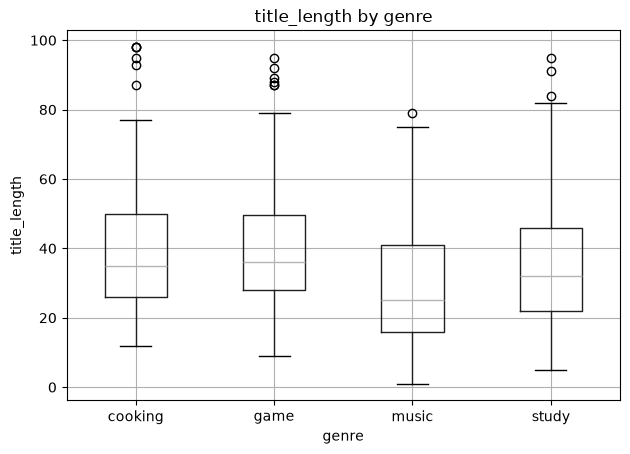

<Figure size 800x400 with 0 Axes>

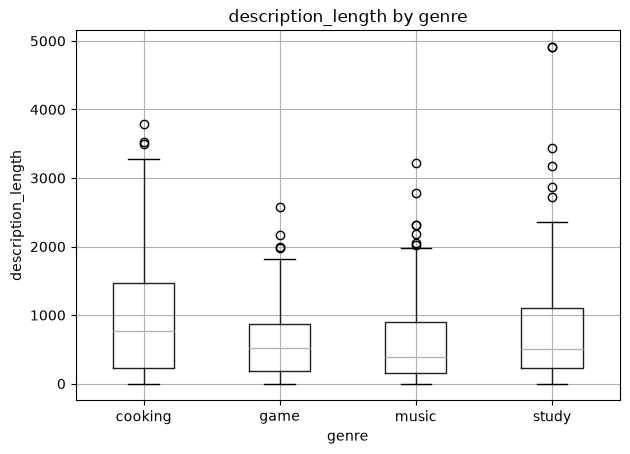

<Figure size 800x400 with 0 Axes>

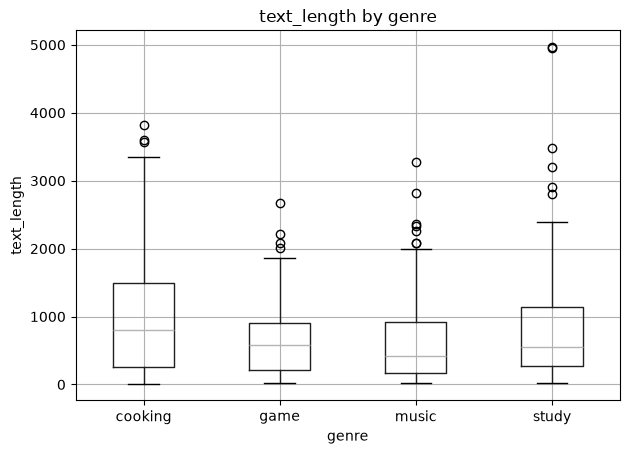

In [94]:
for col in length_cols:
    plt.figure(figsize=(8, 4))
    df.boxplot(column=col, by="genre")
    plt.title(f"{col} by genre")
    plt.suptitle("")
    plt.xlabel("genre")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

<Figure size 800x400 with 0 Axes>

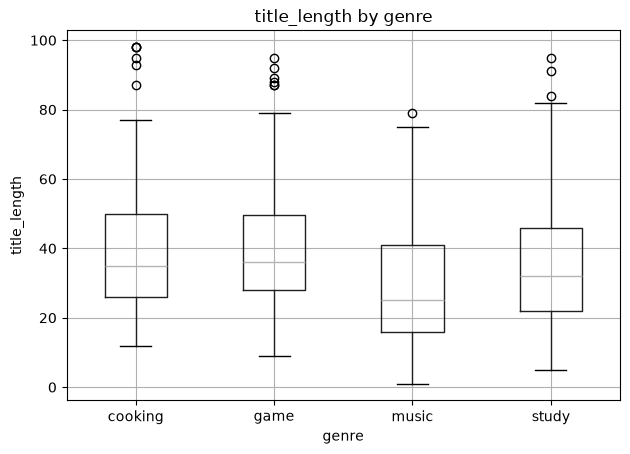

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/outputs/title_length_by_genre_boxplot.png


<Figure size 800x400 with 0 Axes>

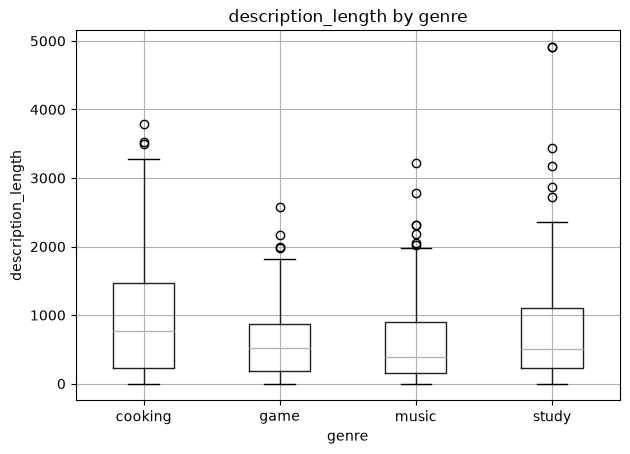

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/outputs/description_length_by_genre_boxplot.png


<Figure size 800x400 with 0 Axes>

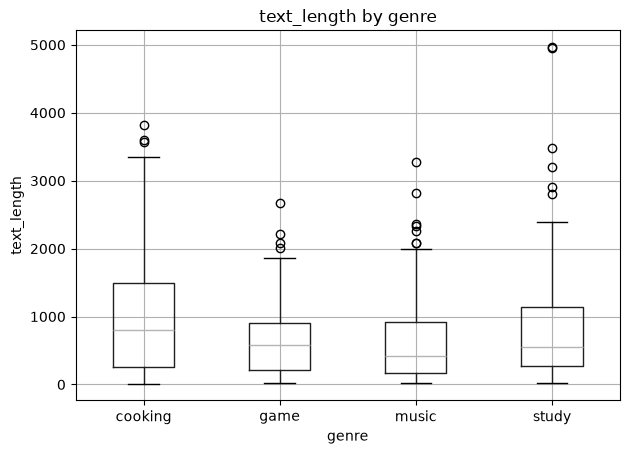

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/outputs/text_length_by_genre_boxplot.png


In [95]:
for col in length_cols:
    plt.figure(figsize=(8, 4))
    df.boxplot(column=col, by="genre")
    plt.title(f"{col} by genre")
    plt.suptitle("")
    plt.xlabel("genre")
    plt.ylabel(col)
    plt.tight_layout()

    output_path = OUTPUTS_DIR / f"{col}_by_genre_boxplot.png"
    plt.savefig(output_path, dpi=150)
    plt.show()

    print("saved:", output_path)

## 7. 概要欄が極端に長い動画を確認する

概要欄が長い動画を実際に確認する。

数値だけでは、概要欄が長い理由までは分からない。

ここでは、文字数が長い動画を上から数件見て、以下を確認する。

* 動画内容の説明が長いのか
* SNSリンクが多いのか
* 商品リンクや配信リンクが多いのか
* ハッシュタグが多いのか
* チャンネルの定型文が多いのか
* 分類に役立つ情報が含まれているのか

この確認によって、概要欄をそのまま分類に使うべきか、後で一部を除去するべきかを考える材料にする。

In [96]:
long_description_df = df.sort_values("description_length", ascending=False)

long_description_df[
    ["genre", "title", "channel_title", "description_length", "url"]
].head(10)

,genre,title,channel_title,description_length,url
292,study,【東京大学出版会 齋藤正彦 線型代数入門】第2章 §5-1 多元一次方程式系の解法、非同次系の一般論,MT 数学・数学史,4909,https://www.youtube.com/watch?v=FXDLNPqucxU
291,study,【東京大学出版会 齋藤正彦 線型代数入門】第一章 §4-4 平面の合同変換、平行移動、回転、鏡映、無限遠点と射影,MT 数学・数学史,4909,https://www.youtube.com/watch?v=EoUjby7EoWc
370,cooking,【最強の時短】冷凍ストック鍋！忙しい日々でも栄養満点の夕食を！,板前シンヤの絶品☆おうちごはん,3789,https://www.youtube.com/watch?v=M8Ga6IU_gWo
401,cooking,【フライドポテトを超える】スウェーデンが生んだ最高峰の芋料理『ハッセルバックポテト』,George ジョージ吉田,3531,https://www.youtube.com/watch?v=78oQWR-3qFE
422,cooking,３００万再生人気レシピ！【漬けるだけ】これが驚くほどウマすぎて市販や居酒屋じゃもう満足出来ない…と何度も言われた『超やべぇキュウリの1/2本漬け』ピリ辛／低糖質／おつまみ／作り置き／副菜／野菜漬け,こっタソの自由気ままに【Kottaso Recipe】,3501,https://www.youtube.com/watch?v=kwWH0Qlc_eg
331,study,【超初心者向け】Premiere ProでYouTubeの動画編集をする流れと方法,Mappy Photo,3441,https://www.youtube.com/watch?v=yoGbTe_rV_M
437,cooking,【鮎の串の打ち方】串の通り道を見える形で解説・鮎 塩焼きの失敗例と化粧塩・Japanese food👉#和食レシピ日本料理案内所,和食レシピ【日本料理案内所】,3277,https://www.youtube.com/watch?v=HDUiz6IesgQ
67,music,Lizzy McAlpine - erase me feat. Jacob Collier (official video),Lizzy McAlpine,3213,https://www.youtube.com/watch?v=YV9NrQvNEv4
261,study,The Continuity of Splines,Freya Holmér,3173,https://www.youtube.com/watch?v=jvPPXbo87ds
235,study,【計25冊】SF読むならまずはここから！ おすすめSF小説マッピング！【前編】,ずんだ文芸部【ざっくり小説紹介】,2866,https://www.youtube.com/watch?v=BfQxlVpnDr8


In [97]:
long_description_preview = long_description_df[
    ["genre", "title", "channel_title", "description_length", "description"]
].head(10).copy()

long_description_preview["description_preview"] = (
    long_description_preview["description"]
    .fillna("")
    .str.replace("\n", " ", regex=False)
    .str[:500]
)

long_description_preview = long_description_preview.drop(columns="description")

display(long_description_preview)

,genre,title,channel_title,description_length,description_preview
292,study,【東京大学出版会 齋藤正彦 線型代数入門】第2章 §5-1 多元一次方程式系の解法、非同次系の一般論,MT 数学・数学史,4909,Contents: Thanks for watching. Please also go to the links below. チャンネル運営と動画制作を支援していただけると幸いです チャンネルメンバーシップはYouTube...
291,study,【東京大学出版会 齋藤正彦 線型代数入門】第一章 §4-4 平面の合同変換、平行移動、回転、鏡映、無限遠点と射影,MT 数学・数学史,4909,Contents: Thanks for watching. Please also go to the links below. チャンネル運営と動画制作を支援していただけると幸いです チャンネルメンバーシップはYouTube...
370,cooking,【最強の時短】冷凍ストック鍋！忙しい日々でも栄養満点の夕食を！,板前シンヤの絶品☆おうちごはん,3789,今回使用したおすすめの食材・調理器具を載せています。 ------------------- 絶品☆おうちごはん＜ポイント＞ ------------------- ①鍋野菜を冷凍してストックして置くことで、忙しい日でも出来立ての...
401,cooking,【フライドポテトを超える】スウェーデンが生んだ最高峰の芋料理『ハッセルバックポテト』,George ジョージ吉田,3531,北欧の国民食、ハッセルバックポテト。アコーディオンのような見た目が華やかで、パーティーのおもてなし料理や、クリスマスにもおすすめです。レストランでは、ステーキの付け合わせに作っていましたが、付け合わせの領域を超える美味しさ。 今回は...
422,cooking,３００万再生人気レシピ！【漬けるだけ】これが驚くほどウマすぎて市販や居酒屋じゃもう満足出来ない…と何度も言われた『超やべぇキュウリの1/2本漬け』ピリ辛／低糖質／おつまみ／作り置き／副菜／野菜漬け,こっタソの自由気ままに【Kottaso Recipe】,3501,◆こっタソ動物園チャンネル 新しいチャンネルです！こちらもおヒマな時にどぞ。 ⇒https://www.youtube.com/c/こっタソ動物園-kottasoanimals ご視聴ありがとうございます。 Thank you f...
331,study,【超初心者向け】Premiere ProでYouTubeの動画編集をする流れと方法,Mappy Photo,3441,Adobe Premiere Pro（アドビプレミアプロ）を使ってYouTubeの動画編集をする流れと方法を解説しました。 初めてPremiere Proを使う方がざっくりでもとりあえず動画を作ることができるようになることを目的と...
437,cooking,【鮎の串の打ち方】串の通り道を見える形で解説・鮎 塩焼きの失敗例と化粧塩・Japanese food👉#和食レシピ日本料理案内所,和食レシピ【日本料理案内所】,3277,【鮎の串打ち方法・鮎の串の刺し方の基本】金串が鮎の内部のどこを通って、どこから出るのかを身が無い状態で見えるように解説しております。 ※ 生きている鮎としめた鮎では金串の打ち方を鮮度によって変化させ、腹が破裂しないよう調節してくださ...
67,music,Lizzy McAlpine - erase me feat. Jacob Collier (official video),Lizzy McAlpine,3213,"‘Older’, the new album from Lizzy McAlpine, is out now. Listen here: https://LizzyMcAlpine.lnk.to/OlderAlbum Liste..."
261,study,The Continuity of Splines,Freya Holmér,3173,"why are splines? well my god I have good news for you, here's why splines! if you like my work, please consider sup..."
235,study,【計25冊】SF読むならまずはここから！ おすすめSF小説マッピング！【前編】,ずんだ文芸部【ざっくり小説紹介】,2866,最近話題の「プロジェクトヘイルメアリー」「三体」を始めとした、これ読んどけば間違いない！というおすすめのSF小説をギュッと詰め込みました！ 「SFって難しそう……」という初心者からSF玄人まで幅広い方にとって有益な情報となるよう、...


In [98]:
for _, row in long_description_df.head(5).iterrows():
    print("=" * 80)
    print("genre:", row["genre"])
    print("title:", row["title"])
    print("channel:", row["channel_title"])
    print("description_length:", row["description_length"])
    print("url:", row["url"])
    print()
    print(str(row["description"])[:1000])
    print()

genre: study
title: 【東京大学出版会 齋藤正彦 線型代数入門】第2章 §5-1 多元一次方程式系の解法、非同次系の一般論
channel: MT 数学・数学史
description_length: 4909
url: https://www.youtube.com/watch?v=FXDLNPqucxU

Contents: Thanks for watching. Please also go to the links below.

チャンネル運営と動画制作を支援していただけると幸いです

チャンネルメンバーシップはYouTubeのチャンネルページから
https://youtube.com/channel/UCA7LZAC55oFU74PnYohV0Tg

クラウドファンディング＆支援コミュニティlink
https://community.camp-fire.jp/projects/view/273185

欲しいものリスト：https://www.amazon.co.jp/hz/wishlist/ls/2UVYOZW56CP47?&sort=price-asc

Twitter link: https://twitter.com/maths_mt?lang=en

Insta link: https://www.instagram.com/mt_mathschannel/

数学史のNoteへのリンク
https://note.com/maths_mt

オンラインや個別指導、仕事などの相談は此方から: 
maths.toshi@gmail.com
-----------------------------------------------------------------

[[リンク集 links]]

オイラーの公式 Euler’s formula 
[27] https://youtu.be/9VC1v1Vwojg
[323] https://youtu.be/5VBxhA8ROzc

フェルマーの小定理プレイリスト Playlist of Fermat’s little theorem.
https://www.youtube.com/playlist?list=PLlA6jgaa1nvgFSD5X50Gb6oYhcQQ

### 文字数確認のまとめ

タイトル・概要欄・結合テキストの文字数を確認した。

特に `description_length` は、動画によって大きく差が出やすい。

概要欄が長い動画については、実際の中身を確認し、以下のどれが多いかを見る。

- 動画内容の説明
- SNSリンク
- 商品リンク
- 配信リンク
- ハッシュタグ
- チャンネルの定型文

この確認結果は、後でURL、ドメイン、ハッシュタグを抽出するときの前提になる。

## 8. URLとドメインを抽出する

概要欄に含まれるURLを抽出し、URLからドメインを取り出す。

URLそのものは非常に種類が多く、そのままでは扱いづらい。

そのため、ここではURL全体ではなく、以下のようなドメイン単位で集計する。

* `youtube.com`
* `youtu.be`
* `twitter.com`
* `x.com`
* `instagram.com`
* `spotify.com`
* `amazon.co.jp`
* `github.com`
* `note.com`

ドメインを見ることで、ジャンルごとの概要欄の使われ方を確認できる。

例えば、音楽動画では配信サービスのリンクが多く、学習動画では教材やGitHubのリンクが多い、といった傾向が見える可能性がある。

In [99]:
url_pattern = re.compile(r"https?://[^\s<>\"]+|www\.[^\s<>\"]+")

def extract_urls(text):
    if pd.isna(text):
        return []
    urls = url_pattern.findall(str(text))
    return [url.strip(".,、。)）]］}」』'\"") for url in urls]

def extract_domain(url):
    url = str(url)
    if url.startswith("www."):
        url = "https://" + url

    parsed = urlparse(url)
    domain = parsed.netloc.lower()

    if domain.startswith("www."):
        domain = domain[4:]

    return domain

In [100]:
df["urls"] = df["description"].apply(extract_urls)
df["url_count"] = df["urls"].apply(len)
df["has_url"] = df["url_count"] > 0

df[["genre", "title", "url_count", "has_url"]].head()

,genre,title,url_count,has_url
0,music,「胎児の夢」 feat.初音ミク,2,True
1,music,天使じゃないよ/初音ミク,2,True
2,music,きおくをみたの/初音ミク(まかろり×いのうつはSA),4,True
3,music,夢憂鬱 / 初音ミク,6,True
4,music,"八月、僕らの犯した間違いの答え合わせ/ カゼヒキ - August, the answer to the mistakes we made",4,True


In [101]:
url_rows = []

for _, row in df.iterrows():
    for url in row["urls"]:
        domain = extract_domain(url)
        if domain:
            url_rows.append({
                "video_id": row["video_id"],
                "genre": row["genre"],
                "title": row["title"],
                "url": url,
                "domain": domain,
            })

url_df = pd.DataFrame(url_rows)

print("URL出現数:", len(url_df))
print("ユニークドメイン数:", url_df["domain"].nunique() if len(url_df) > 0 else 0)

url_df.head()

URL出現数: 2732
ユニークドメイン数: 419


,video_id,genre,title,url,domain
0,ktzbPzmAnnw,music,「胎児の夢」 feat.初音ミク,https://piapro.jp/t/F5n3,piapro.jp
1,ktzbPzmAnnw,music,「胎児の夢」 feat.初音ミク,https://www.nicovideo.jp/my/mylist/68190832?ref=pc_mypage_mylist,nicovideo.jp
2,arlXG7TVdPk,music,天使じゃないよ/初音ミク,https://x.com/echize_nn?s=21&t=nbH4Oc,x.com
3,arlXG7TVdPk,music,天使じゃないよ/初音ミク,https://piapro.jp/t/gHN8,piapro.jp
4,DNltbDXaKw8,music,きおくをみたの/初音ミク(まかろり×いのうつはSA),https://twitter.com/@urayahayahaurra,twitter.com


In [102]:
url_rate_by_genre = df.groupby("genre").agg(
    video_count=("video_id", "count"),
    videos_with_url=("has_url", "sum"),
    mean_url_count=("url_count", "mean"),
    max_url_count=("url_count", "max"),
)

url_rate_by_genre["url_video_rate"] = (
    url_rate_by_genre["videos_with_url"] / url_rate_by_genre["video_count"] * 100
).round(2)

url_rate_by_genre.round(2)

,video_count,videos_with_url,mean_url_count,max_url_count,url_video_rate
genre,,,,,
cooking,102,71,7.76,58,69.61
game,107,89,6.44,32,83.18
music,123,81,3.51,24,65.85
study,111,94,7.38,70,84.68


## 9. ジャンル別の頻出ドメインを確認する

抽出したドメインを、ジャンルごとに集計する。

ここでは、以下の2種類のドメインに注目する。

1. 多くのジャンルに共通して出るドメイン
2. 特定ジャンルに偏って出るドメイン

多くのジャンルに共通して出るドメインは、分類にはあまり役立たない可能性がある。

例えば、どのジャンルにも `youtube.com` や `twitter.com` が多く出てくる場合、それらはジャンル固有の特徴ではなく、YouTube概要欄の定型的な情報と考えられる。

一方で、特定ジャンルに偏って出るドメインは、分類に役立つ可能性がある。

この段階では削除するかどうかを決めきらず、まずは共通ドメインとジャンル固有ドメインを分けて確認する。

In [103]:
domain_occurrence_counts = (
    url_df
    .groupby(["genre", "domain"])
    .size()
    .reset_index(name="url_occurrence_count")
    .sort_values(["genre", "url_occurrence_count"], ascending=[True, False])
)

domain_occurrence_counts.head(20)

,genre,domain,url_occurrence_count
6,cooking,amzn.to,164
87,cooking,youtube.com,124
86,cooking,youtu.be,99
32,cooking,instagram.com,53
2,cooking,amazon.co.jp,44
80,cooking,twitter.com,42
5,cooking,amzn.asia,21
4,cooking,amzlink.to,13
22,cooking,dova-s.jp,13
24,cooking,facebook.com,13


In [104]:
for genre in sorted(df["genre"].unique()):
    print("=" * 80)
    print(genre)

    display(
        domain_occurrence_counts[domain_occurrence_counts["genre"] == genre]
        .head(15)
    )

cooking


,genre,domain,url_occurrence_count
6,cooking,amzn.to,164
87,cooking,youtube.com,124
86,cooking,youtu.be,99
32,cooking,instagram.com,53
2,cooking,amazon.co.jp,44
80,cooking,twitter.com,42
5,cooking,amzn.asia,21
4,cooking,amzlink.to,13
22,cooking,dova-s.jp,13
24,cooking,facebook.com,13


game


,genre,domain,url_occurrence_count
203,game,youtube.com,193
194,game,twitter.com,104
202,game,youtu.be,103
190,game,t.co,23
193,game,twitch.tv,18
186,game,store.line.me,12
97,game,bit.ly,8
188,game,store.steampowered.com,8
201,game,x.com,8
98,game,ch.nicovideo.jp,6


music


,genre,domain,url_occurrence_count
321,music,twitter.com,78
327,music,x.com,48
331,music,youtube.com,32
330,music,youtu.be,29
251,music,instagram.com,20
259,music,linkco.re,13
282,music,nex-tone.link,11
316,music,tiktok.com,8
241,music,facebook.com,7
293,music,piapro.jp,6


study


,genre,domain,url_occurrence_count
499,study,youtu.be,244
500,study,youtube.com,119
340,study,amzn.to,46
485,study,twitter.com,46
395,study,instagram.com,20
385,study,github.com,19
335,study,a.r10.to,13
388,study,goo.gle,10
495,study,x.com,10
381,study,facebook.com,9


In [105]:
video_domain_df = url_df.drop_duplicates(["video_id", "genre", "domain"])

domain_video_counts = (
    video_domain_df
    .groupby(["genre", "domain"])
    .size()
    .reset_index(name="video_count")
    .sort_values(["genre", "video_count"], ascending=[True, False])
)

domain_video_counts.head(20)

,genre,domain,video_count
32,cooking,instagram.com,45
87,cooking,youtube.com,42
80,cooking,twitter.com,41
6,cooking,amzn.to,20
86,cooking,youtu.be,19
2,cooking,amazon.co.jp,18
24,cooking,facebook.com,12
22,cooking,dova-s.jp,11
79,cooking,tiktok.com,11
62,cooking,pinterest.jp,7


In [106]:
for genre in sorted(df["genre"].unique()):
    print("=" * 80)
    print(genre)

    display(
        domain_video_counts[domain_video_counts["genre"] == genre]
        .head(15)
    )

cooking


,genre,domain,video_count
32,cooking,instagram.com,45
87,cooking,youtube.com,42
80,cooking,twitter.com,41
6,cooking,amzn.to,20
86,cooking,youtu.be,19
2,cooking,amazon.co.jp,18
24,cooking,facebook.com,12
22,cooking,dova-s.jp,11
79,cooking,tiktok.com,11
62,cooking,pinterest.jp,7


game


,genre,domain,video_count
203,game,youtube.com,59
194,game,twitter.com,52
202,game,youtu.be,29
193,game,twitch.tv,15
188,game,store.steampowered.com,8
201,game,x.com,8
98,game,ch.nicovideo.jp,6
104,game,discord.gg,6
107,game,dova-s.jp,6
126,game,instagram.com,5


music


,genre,domain,video_count
321,music,twitter.com,36
331,music,youtube.com,21
327,music,x.com,18
251,music,instagram.com,17
330,music,youtu.be,15
259,music,linkco.re,13
316,music,tiktok.com,8
241,music,facebook.com,7
293,music,piapro.jp,6
308,music,soundcloud.com,6


study


,genre,domain,video_count
500,study,youtube.com,52
485,study,twitter.com,38
499,study,youtu.be,34
395,study,instagram.com,16
340,study,amzn.to,15
385,study,github.com,11
495,study,x.com,9
442,study,open.spotify.com,8
381,study,facebook.com,7
437,study,note.com,7


## 10. 共通ドメインを削除候補として整理する

ジャンル別のドメイン集計をもとに、どのジャンルにも共通して出てくるドメインを削除候補として整理する。

ここでは、例えば以下のような条件を考える。

* 3ジャンル以上に出現している
* 出現回数が一定以上ある
* 特定ジャンルへの偏りが小さい
* YouTubeやSNSなど、動画内容より投稿者の定型情報を表していそうである

このようなドメインは、分類モデルがジャンルではなく概要欄テンプレートを学習してしまう原因になる可能性がある。

そのため、後の前処理で削除する候補として記録しておく。

In [107]:
domain_genre_pivot = (
    video_domain_df
    .groupby(["domain", "genre"])
    .size()
    .unstack(fill_value=0)
)

domain_genre_pivot["total_video_count"] = domain_genre_pivot.sum(axis=1)
domain_genre_pivot["n_genres"] = (domain_genre_pivot.drop(columns="total_video_count") > 0).sum(axis=1)
domain_genre_pivot["max_genre_count"] = domain_genre_pivot.drop(
    columns=["total_video_count", "n_genres"]
).max(axis=1)
domain_genre_pivot["max_genre_ratio"] = (
    domain_genre_pivot["max_genre_count"] / domain_genre_pivot["total_video_count"]
)

domain_genre_summary = (
    domain_genre_pivot
    .sort_values(["n_genres", "total_video_count"], ascending=False)
)

domain_genre_summary.head(30)

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
domain,,,,,,,,
youtube.com,42,59,21,52,174,4,59,0.339080
twitter.com,41,52,36,38,167,4,52,0.311377
youtu.be,19,29,15,34,97,4,34,0.350515
instagram.com,45,5,17,16,83,4,45,0.542169
amzn.to,20,2,1,15,38,4,20,0.526316
facebook.com,12,1,7,7,27,4,12,0.444444
amazon.co.jp,18,1,2,5,26,4,18,0.692308
tiktok.com,11,3,8,3,25,4,11,0.440000
bit.ly,6,4,2,6,18,4,6,0.333333


In [108]:
common_domain_candidates = domain_genre_summary[
    (domain_genre_summary["n_genres"] >= 3)
    & (domain_genre_summary["total_video_count"] >= 5)
    & (domain_genre_summary["max_genre_ratio"] <= 0.7)
].copy()

common_domain_candidates

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
domain,,,,,,,,
youtube.com,42,59,21,52,174,4,59,0.339080
twitter.com,41,52,36,38,167,4,52,0.311377
youtu.be,19,29,15,34,97,4,34,0.350515
instagram.com,45,5,17,16,83,4,45,0.542169
amzn.to,20,2,1,15,38,4,20,0.526316
facebook.com,12,1,7,7,27,4,12,0.444444
amazon.co.jp,18,1,2,5,26,4,18,0.692308
tiktok.com,11,3,8,3,25,4,11,0.440000
bit.ly,6,4,2,6,18,4,6,0.333333


In [109]:
genre_specific_domain_candidates = domain_genre_summary[
    (domain_genre_summary["total_video_count"] >= 3)
    & (domain_genre_summary["max_genre_ratio"] >= 0.8)
].copy()

genre_specific_domain_candidates.head(30)

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
domain,,,,,,,,
twitch.tv,0,15,0,1,16,2,15,0.937500
linkco.re,1,0,13,0,14,2,13,0.928571
github.com,0,1,0,11,12,2,11,0.916667
store.steampowered.com,0,8,0,1,9,2,8,0.888889
vt.tiktok.com,6,1,0,0,7,2,6,0.857143
forms.gle,0,1,0,5,6,2,5,0.833333
maoudamashii.jokersounds.com,1,5,0,0,6,2,5,0.833333
a.r10.to,4,0,0,1,5,2,4,0.800000
pinterest.jp,7,0,0,0,7,1,7,1.000000


In [110]:
common_domains = common_domain_candidates.index.tolist()

common_domains

['youtube.com',
 'twitter.com',
 'youtu.be',
 'instagram.com',
 'amzn.to',
 'facebook.com',
 'amazon.co.jp',
 'tiktok.com',
 'bit.ly',
 'goo.gl',
 'note.com',
 'x.com',
 'dova-s.jp',
 'soundeffect-lab.info',
 'musmus.main.jp',
 'line.me',
 'nicovideo.jp',
 'otologic.jp',
 'amzn.asia',
 'mobile.twitter.com']

In [111]:
domain_candidate_summary = pd.DataFrame({
    "common_domain_candidates": pd.Series(common_domains),
})

domain_candidate_summary

,common_domain_candidates
0,youtube.com
1,twitter.com
2,youtu.be
3,instagram.com
4,amzn.to
5,facebook.com
6,amazon.co.jp
7,tiktok.com
8,bit.ly
9,goo.gl


### ドメイン確認のまとめ

概要欄からURLを抽出し、URLからドメインを取り出した。

ドメインについては、単純なURL出現回数だけでなく、同じ動画内で同じドメインが複数回出た場合を1回として数える `video_count` も確認した。

今回の方針では、以下のように扱う。

- 多くのジャンルに共通して出るドメイン: 削除候補
- 特定ジャンルに偏って出るドメイン: 分類に有用な特徴候補

共通ドメインの候補は、後の前処理で削除対象として検討する。

ただし、この段階ではまだ削除は行わず、まずは候補として記録する。

## 11. ハッシュタグを抽出する

概要欄に含まれるハッシュタグを抽出する。

ハッシュタグは、単純なノイズとは限らない。

例えば、以下のようなハッシュタグはジャンル分類に役立つ可能性がある。

* `#歌ってみた`
* `#cover`
* `#ゲーム実況`
* `#レシピ`
* `#料理`
* `#数学`
* `#Python`
* `#勉強`

一方で、以下のようなハッシュタグはジャンルに関係なく出る可能性がある。

* `#shorts`
* `#youtube`
* `#おすすめ`

そのため、ハッシュタグは削除対象として一括で扱うのではなく、ジャンル別の出現傾向を確認する。

In [112]:
hashtag_pattern = re.compile(r"(?<![A-Za-z0-9_/])#([^\s#]+)")

def normalize_hashtag(tag):
    tag = str(tag).strip()
    tag = tag.strip(".,、。!！?？:：;；)）]］}」』'\"")
    return "#" + tag.lower()

def extract_hashtags(text):
    if pd.isna(text):
        return []

    tags = hashtag_pattern.findall(str(text))
    return [normalize_hashtag(tag) for tag in tags if tag.strip()]

In [113]:
df["hashtag_source_text"] = (
    df["title"].fillna("") + "\n" + df["description"].fillna("")
)

df["hashtags"] = df["hashtag_source_text"].apply(extract_hashtags)
df["hashtag_count"] = df["hashtags"].apply(len)
df["has_hashtag"] = df["hashtag_count"] > 0

df[["genre", "title", "hashtag_count", "has_hashtag"]].head()

,genre,title,hashtag_count,has_hashtag
0,music,「胎児の夢」 feat.初音ミク,0,False
1,music,天使じゃないよ/初音ミク,4,True
2,music,きおくをみたの/初音ミク(まかろり×いのうつはSA),0,False
3,music,夢憂鬱 / 初音ミク,1,True
4,music,"八月、僕らの犯した間違いの答え合わせ/ カゼヒキ - August, the answer to the mistakes we made",3,True


In [114]:
hashtag_rows = []

for _, row in df.iterrows():
    for hashtag in row["hashtags"]:
        hashtag_rows.append({
            "video_id": row["video_id"],
            "genre": row["genre"],
            "title": row["title"],
            "hashtag": hashtag,
        })

hashtag_df = pd.DataFrame(hashtag_rows)

print("ハッシュタグ出現数:", len(hashtag_df))
print("ユニークハッシュタグ数:", hashtag_df["hashtag"].nunique() if len(hashtag_df) > 0 else 0)

hashtag_df.head()

ハッシュタグ出現数: 1053
ユニークハッシュタグ数: 829


,video_id,genre,title,hashtag
0,arlXG7TVdPk,music,天使じゃないよ/初音ミク,#vocaloid
1,arlXG7TVdPk,music,天使じゃないよ/初音ミク,#初音ミク
2,arlXG7TVdPk,music,天使じゃないよ/初音ミク,#ボカロ
3,arlXG7TVdPk,music,天使じゃないよ/初音ミク,#オリジナル曲
4,JqvE2fxm80U,music,夢憂鬱 / 初音ミク,#vocaduo2024vv


In [115]:
hashtag_rate_by_genre = df.groupby("genre").agg(
    video_count=("video_id", "count"),
    videos_with_hashtag=("has_hashtag", "sum"),
    mean_hashtag_count=("hashtag_count", "mean"),
    max_hashtag_count=("hashtag_count", "max"),
)

hashtag_rate_by_genre["hashtag_video_rate"] = (
    hashtag_rate_by_genre["videos_with_hashtag"] / hashtag_rate_by_genre["video_count"] * 100
).round(2)

hashtag_rate_by_genre.round(2)

,video_count,videos_with_hashtag,mean_hashtag_count,max_hashtag_count,hashtag_video_rate
genre,,,,,
cooking,102,70,3.98,61,68.63
game,107,59,1.76,15,55.14
music,123,37,1.78,38,30.08
study,111,54,2.16,17,48.65


## 12. ジャンル別の頻出ハッシュタグを確認する

抽出したハッシュタグを、ジャンルごとに集計する。

ここでは、以下の2種類のハッシュタグに注目する。

1. 多くのジャンルに共通して出るハッシュタグ
2. 特定ジャンルに偏って出るハッシュタグ

特定ジャンルに偏って出るハッシュタグは、分類に役立つ特徴である可能性が高い。

一方で、どのジャンルにも出るハッシュタグは、ジャンル分類にはあまり役立たない可能性がある。

この確認によって、残すべきハッシュタグと、削除候補にするハッシュタグを分けるための材料にする。

In [116]:
hashtag_occurrence_counts = (
    hashtag_df
    .groupby(["genre", "hashtag"])
    .size()
    .reset_index(name="hashtag_occurrence_count")
    .sort_values(["genre", "hashtag_occurrence_count"], ascending=[True, False])
)

hashtag_occurrence_counts.head(20)

,genre,hashtag,hashtag_occurrence_count
35,cooking,#shorts,33
240,cooking,#簡単レシピ,14
196,cooking,#料理,10
169,cooking,#作り置き,6
241,cooking,#簡単料理,5
155,cooking,#リュウジ,4
205,cooking,#時短レシピ,4
33,cooking,#short,3
42,cooking,#おうちごはん,3
53,cooking,#かんたんレシピ,3


In [117]:
for genre in sorted(df["genre"].unique()):
    print("=" * 80)
    print(genre)

    display(
        hashtag_occurrence_counts[hashtag_occurrence_counts["genre"] == genre]
        .head(20)
    )

cooking


,genre,hashtag,hashtag_occurrence_count
35,cooking,#shorts,33
240,cooking,#簡単レシピ,14
196,cooking,#料理,10
169,cooking,#作り置き,6
241,cooking,#簡単料理,5
155,cooking,#リュウジ,4
205,cooking,#時短レシピ,4
33,cooking,#short,3
42,cooking,#おうちごはん,3
53,cooking,#かんたんレシピ,3


game


,genre,hashtag,hashtag_occurrence_count
336,game,#あらなみマイクラ,5
294,game,#1,4
325,game,#rta,3
358,game,#ゆっくり実況,3
365,game,#ゲーム,3
399,game,#マイクラ,3
403,game,#マインクラフト,3
437,game,#裏技,3
318,game,#kun,2
319,game,#minecraft,2


music


,genre,hashtag,hashtag_occurrence_count
532,music,#vocaloid,5
529,music,#utau,3
588,music,#初音ミク,3
616,music,#歌ってみた,3
479,music,#hatsunemiku,2
491,music,#jpop,2
545,music,#エモい,2
546,music,#エモい曲,2
549,music,#オリジナル曲,2
584,music,#人工言語,2


study


,genre,hashtag,hashtag_occurrence_count
699,study,#toeic,5
767,study,#大学受験,5
702,study,#toeic対策,4
660,study,#ai,3
762,study,#地理,3
787,study,#数学,3
789,study,#日本史,3
668,study,#dtm,2
674,study,#g検定,2
675,study,#html,2


In [118]:
video_hashtag_df = hashtag_df.drop_duplicates(["video_id", "genre", "hashtag"])

hashtag_video_counts = (
    video_hashtag_df
    .groupby(["genre", "hashtag"])
    .size()
    .reset_index(name="video_count")
    .sort_values(["genre", "video_count"], ascending=[True, False])
)

hashtag_video_counts.head(20)

,genre,hashtag,video_count
35,cooking,#shorts,23
240,cooking,#簡単レシピ,13
196,cooking,#料理,8
169,cooking,#作り置き,6
205,cooking,#時短レシピ,4
42,cooking,#おうちごはん,3
53,cooking,#かんたんレシピ,3
115,cooking,#ダイエットレシピ,3
176,cooking,#和食,3
199,cooking,#料理男子,3


In [119]:
for genre in sorted(df["genre"].unique()):
    print("=" * 80)
    print(genre)

    display(
        hashtag_video_counts[hashtag_video_counts["genre"] == genre]
        .head(20)
    )

cooking


,genre,hashtag,video_count
35,cooking,#shorts,23
240,cooking,#簡単レシピ,13
196,cooking,#料理,8
169,cooking,#作り置き,6
205,cooking,#時短レシピ,4
42,cooking,#おうちごはん,3
53,cooking,#かんたんレシピ,3
115,cooking,#ダイエットレシピ,3
176,cooking,#和食,3
199,cooking,#料理男子,3


game


,genre,hashtag,video_count
294,game,#1,4
325,game,#rta,3
358,game,#ゆっくり実況,3
365,game,#ゲーム,3
399,game,#マイクラ,3
403,game,#マインクラフト,3
437,game,#裏技,3
318,game,#kun,2
319,game,#minecraft,2
350,game,#のばまん,2


music


,genre,hashtag,video_count
532,music,#vocaloid,5
529,music,#utau,3
588,music,#初音ミク,3
616,music,#歌ってみた,3
479,music,#hatsunemiku,2
491,music,#jpop,2
546,music,#エモい曲,2
549,music,#オリジナル曲,2
449,music,#01,1
450,music,#246,1


study


,genre,hashtag,video_count
699,study,#toeic,5
767,study,#大学受験,5
702,study,#toeic対策,4
660,study,#ai,3
762,study,#地理,3
787,study,#数学,3
789,study,#日本史,3
668,study,#dtm,2
674,study,#g検定,2
675,study,#html,2


## 13. 共通ハッシュタグを削除候補として整理する

ジャンル別のハッシュタグ集計をもとに、どのジャンルにも共通して出てくるハッシュタグを削除候補として整理する。

ここでは、例えば以下のような条件を考える。

* 3ジャンル以上に出現している
* 出現回数が一定以上ある
* 特定ジャンルへの偏りが小さい
* `#shorts` のように、動画形式を表すだけでジャンルを表していない

このようなハッシュタグは、後の前処理で削除する候補として記録しておく。

ただし、ハッシュタグを削除するかどうかは、このEDAだけで最終決定しない。

まずは、削除候補を整理し、分類実験で「削除前」と「削除後」を比較できるようにする。

In [120]:
hashtag_genre_pivot = (
    video_hashtag_df
    .groupby(["hashtag", "genre"])
    .size()
    .unstack(fill_value=0)
)

hashtag_genre_pivot["total_video_count"] = hashtag_genre_pivot.sum(axis=1)
hashtag_genre_pivot["n_genres"] = (
    hashtag_genre_pivot.drop(columns="total_video_count") > 0
).sum(axis=1)

hashtag_genre_pivot["max_genre_count"] = hashtag_genre_pivot.drop(
    columns=["total_video_count", "n_genres"]
).max(axis=1)

hashtag_genre_pivot["max_genre_ratio"] = (
    hashtag_genre_pivot["max_genre_count"] / hashtag_genre_pivot["total_video_count"]
)

hashtag_genre_summary = hashtag_genre_pivot.sort_values(
    ["n_genres", "total_video_count"],
    ascending=False,
)

hashtag_genre_summary.head(30)

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
hashtag,,,,,,,,
#shorts,23,1,0,1,25,3,23,0.920000
#vocaloid,0,0,5,1,6,2,5,0.833333
#1,0,4,0,1,5,2,4,0.800000
#ブルーアーカイブ,0,2,1,0,3,2,2,0.666667
#3,0,1,0,1,2,2,1,0.500000
#vtuber,0,1,1,0,2,2,1,0.500000
#英語リスニング,1,0,0,1,2,2,1,0.500000
#音楽理論,0,0,1,1,2,2,1,0.500000
#簡単レシピ,13,0,0,0,13,1,13,1.000000


In [121]:
common_hashtag_candidates = hashtag_genre_summary[
    (hashtag_genre_summary["n_genres"] >= 3)
    & (hashtag_genre_summary["total_video_count"] >= 5)
    & (hashtag_genre_summary["max_genre_ratio"] <= 0.7)
].copy()

common_hashtag_candidates

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
hashtag,,,,,,,,


In [122]:
genre_specific_hashtag_candidates = hashtag_genre_summary[
    (hashtag_genre_summary["total_video_count"] >= 3)
    & (hashtag_genre_summary["max_genre_ratio"] >= 0.8)
].copy()

genre_specific_hashtag_candidates.head(50)

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
hashtag,,,,,,,,
#shorts,23,1,0,1,25,3,23,0.920000
#vocaloid,0,0,5,1,6,2,5,0.833333
#1,0,4,0,1,5,2,4,0.800000
#簡単レシピ,13,0,0,0,13,1,13,1.000000
#料理,8,0,0,0,8,1,8,1.000000
#作り置き,6,0,0,0,6,1,6,1.000000
#toeic,0,0,0,5,5,1,5,1.000000
#大学受験,0,0,0,5,5,1,5,1.000000
#toeic対策,0,0,0,4,4,1,4,1.000000


In [123]:
common_hashtags = common_hashtag_candidates.index.tolist()

common_hashtags

[]

In [124]:
hashtag_candidate_summary = pd.DataFrame({
    "common_hashtag_candidates": pd.Series(common_hashtags),
})

hashtag_candidate_summary

,common_hashtag_candidates


### ハッシュタグ確認のまとめ

タイトルと概要欄からハッシュタグを抽出し、ジャンル別に集計した。

ハッシュタグについても、単純な出現回数だけでなく、同じ動画内で同じハッシュタグが複数回出た場合を1回として数える `video_count` も確認した。

今回の方針では、以下のように扱う。

- 多くのジャンルに共通して出るハッシュタグ: 削除候補
- 特定ジャンルに偏って出るハッシュタグ: 分類に有用な特徴候補

共通ハッシュタグの候補は、後の前処理で削除対象として検討する。

ただし、この段階ではまだ削除は行わず、まずは候補として記録する。

## 14. ジャンル別の特徴語を確認する

次に、ジャンルごとの特徴語を確認する。

ここでは、動画タイトルや概要欄に出てくる語のうち、特定ジャンルに偏って出ているものを探す。

タイトル例を数件見るだけでは、ジャンルごとの傾向は分かりにくい。

そのため、単語や短い語句の出現傾向を集計し、ジャンルごとに特徴的な語を確認する。

この確認は、後でTF-IDF + ロジスティック回帰を使った分類結果を解釈するときの参考になる。

In [125]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

In [126]:
def get_genre_top_tfidf_features(
    df,
    text_col,
    label_col="genre",
    top_n=20,
    ngram_range=(2, 6),
    min_df=2,
    max_df=0.85,
    max_features=5000,
):
    texts = df[text_col].fillna("").astype(str)
    labels = df[label_col].to_numpy()

    vectorizer = TfidfVectorizer(
        analyzer="char",
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df,
        max_features=max_features,
        sublinear_tf=True,
    )

    X = vectorizer.fit_transform(texts)
    feature_names = np.array(vectorizer.get_feature_names_out())

    rows = []

    for genre in sorted(np.unique(labels)):
        genre_mask = labels == genre
        other_mask = labels != genre

        genre_mean = np.asarray(X[genre_mask].mean(axis=0)).ravel()
        other_mean = np.asarray(X[other_mask].mean(axis=0)).ravel()

        distinctive_score = genre_mean - other_mean
        top_indices = distinctive_score.argsort()[::-1][:top_n]

        for rank, idx in enumerate(top_indices, start=1):
            rows.append({
                "genre": genre,
                "rank": rank,
                "feature": feature_names[idx],
                "genre_mean_tfidf": genre_mean[idx],
                "other_mean_tfidf": other_mean[idx],
                "distinctive_score": distinctive_score[idx],
            })

    return pd.DataFrame(rows)

In [127]:
title_top_features = get_genre_top_tfidf_features(
    df,
    text_col="title",
    top_n=20,
    ngram_range=(2, 6),
    min_df=2,
    max_df=0.85,
)

title_top_features.head()

,genre,rank,feature,genre_mean_tfidf,other_mean_tfidf,distinctive_score
0,cooking,1,作り,0.030078,0.001194,0.028883
1,cooking,2,シピ,0.025553,0.000000,0.025553
2,cooking,3,レシピ,0.025553,0.000000,0.025553
3,cooking,4,レシ,0.025553,0.000000,0.025553
4,cooking,5,ho,0.025909,0.002095,0.023814


In [128]:
for genre in sorted(df["genre"].unique()):
    print("=" * 80)
    print(genre)

    display(
        title_top_features[title_top_features["genre"] == genre]
        [["rank", "feature", "distinctive_score", "genre_mean_tfidf", "other_mean_tfidf"]]
    )

cooking


,rank,feature,distinctive_score,genre_mean_tfidf,other_mean_tfidf
0,1,作り,0.028883,0.030078,0.001194
1,2,シピ,0.025553,0.025553,0.000000
2,3,レシピ,0.025553,0.025553,0.000000
3,4,レシ,0.025553,0.025553,0.000000
4,5,ho,0.023814,0.025909,0.002095
5,6,#short,0.022980,0.023591,0.000610
6,7,hort,0.022980,0.023591,0.000610
7,8,hor,0.022980,0.023591,0.000610
8,9,#sh,0.022980,0.023591,0.000610
9,10,#sho,0.022980,0.023591,0.000610


game


,rank,feature,distinctive_score,genre_mean_tfidf,other_mean_tfidf
20,1,クラ,0.019485,0.020100,0.000615
21,2,実況,0.018663,0.019089,0.000426
22,3,レイ,0.016310,0.017145,0.000835
23,4,マイ,0.015648,0.015648,0.000000
24,5,プレイ,0.014369,0.014857,0.000488
25,6,rta,0.013747,0.013747,0.000000
26,7,プレ,0.013738,0.014582,0.000844
27,8,バグ,0.012057,0.012057,0.000000
28,9,カー,0.012037,0.012037,0.000000
29,10,実況】,0.011832,0.011832,0.000000


music


,rank,feature,distinctive_score,genre_mean_tfidf,other_mean_tfidf
40,1,-,0.034834,0.036246,0.001413
41,2,-,0.034122,0.035554,0.001432
42,3,-,0.033763,0.035896,0.002133
43,4,(,0.016735,0.018478,0.001743
44,5,/,0.016575,0.016914,0.000339
45,6,/,0.016575,0.016914,0.000339
46,7,/,0.016350,0.017564,0.001214
47,8,ov,0.015787,0.016219,0.000432
48,9,音ミ,0.015322,0.015322,0.000000
49,10,音ミク,0.015322,0.015322,0.000000


study


,rank,feature,distinctive_score,genre_mean_tfidf,other_mean_tfidf
60,1,数学,0.018551,0.018551,0.000000
61,2,空間,0.015757,0.015757,0.000000
62,3,線形,0.012898,0.012898,0.000000
63,4,地理,0.012088,0.012088,0.000000
64,5,解説,0.011937,0.014567,0.002630
65,6,次元,0.011321,0.011321,0.000000
66,7,積分,0.010741,0.010741,0.000000
67,8,関数,0.009671,0.009671,0.000000
68,9,気候,0.009571,0.009571,0.000000
69,10,講義,0.008935,0.008935,0.000000


In [129]:
text_base_top_features = get_genre_top_tfidf_features(
    df,
    text_col="text_base",
    top_n=20,
    ngram_range=(2, 6),
    min_df=2,
    max_df=0.85,
)

text_base_top_features.head()

,genre,rank,feature,genre_mean_tfidf,other_mean_tfidf,distinctive_score
0,cooking,1,レシピ,0.036335,0.000062,0.036273
1,cooking,2,レシ,0.036335,0.000062,0.036273
2,cooking,3,シピ,0.036335,0.000062,0.036273
3,cooking,4,さじ,0.030562,0.000000,0.030562
4,cooking,5,大さ,0.027184,0.000000,0.027184


In [130]:
for genre in sorted(df["genre"].unique()):
    print("=" * 80)
    print(genre)

    display(
        text_base_top_features[text_base_top_features["genre"] == genre]
        [["rank", "feature", "distinctive_score", "genre_mean_tfidf", "other_mean_tfidf"]]
    )

cooking


,rank,feature,distinctive_score,genre_mean_tfidf,other_mean_tfidf
0,1,レシピ,0.036273,0.036335,0.000062
1,2,レシ,0.036273,0.036335,0.000062
2,3,シピ,0.036273,0.036335,0.000062
3,4,さじ,0.030562,0.030562,0.000000
4,5,大さ,0.027184,0.027184,0.000000
5,6,大さじ,0.027184,0.027184,0.000000
6,7,料理,0.025841,0.025841,0.000000
7,8,hort,0.022468,0.023062,0.000594
8,9,short,0.022468,0.023062,0.000594
9,10,#short,0.022457,0.022817,0.000361


game


,rank,feature,distinctive_score,genre_mean_tfidf,other_mean_tfidf
20,1,実況,0.020242,0.020989,0.000747
21,2,ゲー,0.016171,0.018240,0.002069
22,3,バグ,0.016048,0.016048,0.000000
23,4,ゲーム,0.015512,0.016859,0.001347
24,5,レイ,0.014940,0.017472,0.002532
25,6,マイ,0.013721,0.015003,0.001282
26,7,プレイ,0.013667,0.015415,0.001748
27,8,】,0.012415,0.017483,0.005068
28,9,ポケ,0.012072,0.012139,0.000067
29,10,tw,0.011285,0.022346,0.011061


music


,rank,feature,distinctive_score,genre_mean_tfidf,other_mean_tfidf
40,1,-,0.017197,0.020879,0.003682
41,2,-,0.017150,0.019476,0.002326
42,3,-,0.016743,0.021691,0.004948
43,4,y,0.016443,0.019374,0.002930
44,5,:,0.016272,0.023086,0.006815
45,6,d,0.015853,0.023453,0.007600
46,7,e,0.014824,0.026864,0.012040
47,8,yo,0.014751,0.017310,0.002559
48,9,m,0.014172,0.021995,0.007823
49,10,sic,0.014005,0.016856,0.002851


study


,rank,feature,distinctive_score,genre_mean_tfidf,other_mean_tfidf
60,1,講義,0.024142,0.024142,0.000000
61,2,解説,0.022372,0.023878,0.001506
62,3,大学,0.020882,0.021150,0.000267
63,4,関数,0.016972,0.016972,0.000000
64,5,す。,0.016102,0.027351,0.011249
65,6,数学,0.015995,0.015995,0.000000
66,7,ます。,0.015896,0.023789,0.007893
67,8,ます,0.013508,0.027156,0.013647
68,9,\n0,0.013102,0.016482,0.003381
69,10,いて,0.012981,0.018160,0.005179


In [131]:
title_feature_set = set(title_top_features["feature"])
text_base_feature_set = set(text_base_top_features["feature"])

print("title 上位特徴数:", len(title_feature_set))
print("text_base 上位特徴数:", len(text_base_feature_set))
print("共通特徴数:", len(title_feature_set & text_base_feature_set))

title 上位特徴数: 80
text_base 上位特徴数: 80
共通特徴数: 30


In [132]:
for genre in sorted(df["genre"].unique()):
    title_features = set(
        title_top_features[title_top_features["genre"] == genre]["feature"]
    )
    text_base_features = set(
        text_base_top_features[text_base_top_features["genre"] == genre]["feature"]
    )

    print("=" * 80)
    print(genre)
    print("titleのみ:", sorted(title_features - text_base_features)[:20])
    print("text_baseのみ:", sorted(text_base_features - title_features)[:20])
    print("共通:", sorted(title_features & text_base_features)[:20])

cooking
titleのみ: [' #', '#s', 'ho', 'sho', '作り']
text_baseのみ: ['さじ', '大さ', '大さじ', '料理', '簡単']
共通: ['#sh', '#sho', '#shor', '#short', 'hor', 'hort', 'horts', 'orts', 'rts', 'shor', 'short', 'shorts', 'シピ', 'レシ', 'レシピ']
game
titleのみ: ['rta', '【マ', '【マイ', 'した', 'ゆっ', 'ゆっく', 'ゆっくり', 'カー', 'クラ', 'クリア', 'ター', 'プレ', 'モン', '実況】', '況】']
text_baseのみ: ['.yout', '.youtu', '/st', 'tch', 'tw', 'w.yo', 'w.you', 'w.yout', 'ww.yo', 'ww.you', 'www.yo', '】 ', 'ゲー', 'ゲーム', 'ポケ']
共通: ['バグ', 'プレイ', 'マイ', 'レイ', '実況']
music
titleのみ: [' (', ' /', ' / ', '/ ', 'er', 'ic', 'me', 'ov', 've', 'ミク', '初音', '初音ミ', '初音ミク', '音ミ', '音ミク']
text_baseのみ: [' b', ' o', ' y', ' yo', ' you', ': ', 'al', 'd ', 'lyri', 'lyric', 'musi', 'music', 'sic', 'usic', 'yric']
共通: [' -', ' - ', ' m', '- ', 'e ']
study
titleのみ: ['の解', '何か', '入門', '地理', '地理】', '学】', '学部', '次元', '気候', '物理', '積分', '空間', '統計', '線形', '高校']
text_baseのみ: ['\n0', ':0', 'いて', 'います', 'います。', 'す。', 'ついて', 'ていま', 'につ', 'につい', 'について', 'ます', 'ます。', '問題', '大学']
共通: ['動画',

In [133]:
noise_like_patterns = [
    "http",
    "www",
    ".com",
    ".jp",
    "://",
    "#",
    "twitter",
    "instagram",
    "youtube",
    "youtu.be",
]

def is_noise_like_feature(feature):
    feature_lower = str(feature).lower()
    return any(pattern in feature_lower for pattern in noise_like_patterns)

In [134]:
text_base_top_features["is_noise_like"] = text_base_top_features["feature"].apply(
    is_noise_like_feature
)

text_base_top_features[text_base_top_features["is_noise_like"]]

,genre,rank,feature,genre_mean_tfidf,other_mean_tfidf,distinctive_score,is_noise_like
9,cooking,10,#short,0.022817,0.000361,0.022457,True
10,cooking,11,#sho,0.022817,0.000361,0.022457,True
11,cooking,12,#shor,0.022817,0.000361,0.022457,True
15,cooking,16,#sh,0.022388,0.000595,0.021793,True
33,game,14,www.yo,0.018644,0.007717,0.010927,True


In [135]:
noise_like_count_by_genre = (
    text_base_top_features
    .groupby("genre")["is_noise_like"]
    .sum()
    .sort_values(ascending=False)
)

noise_like_count_by_genre

genre
cooking    4
game       1
music      0
study      0
Name: is_noise_like, dtype: int64

In [136]:
title_top_features.to_csv(
    OUTPUTS_DIR / "title_top_features_by_genre.csv",
    index=False,
)

text_base_top_features.to_csv(
    OUTPUTS_DIR / "text_base_top_features_by_genre.csv",
    index=False,
)

print("saved:", OUTPUTS_DIR / "title_top_features_by_genre.csv")
print("saved:", OUTPUTS_DIR / "text_base_top_features_by_genre.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/outputs/title_top_features_by_genre.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/outputs/text_base_top_features_by_genre.csv


### 特徴語確認のまとめ

タイトルと `text_base` について、ジャンルごとに特徴的な文字列を確認した。

日本語の形態素解析はまだ使わず、文字n-gramのTF-IDFを使って確認した。

この方法では、厳密な単語ではなく、ジャンルごとに出やすい短い文字列を確認している。

確認した内容は以下である。

- タイトルだけで見たジャンル別の特徴的な文字列
- `title + description` で見たジャンル別の特徴的な文字列
- タイトル由来の特徴と概要欄込みの特徴の違い
- URL・ハッシュタグ・ドメイン由来の文字列が上位に出ているか

もし `text_base` の上位特徴にURLやSNS、汎用ハッシュタグ由来の文字列が多く出る場合、概要欄の定型情報が分類特徴に強く入っている可能性がある。

一方で、特定ジャンルに偏って出る文字列は、分類に役立つ特徴である可能性がある。

この結果は、後でTF-IDF + ロジスティック回帰の分類結果や、共通ドメイン・共通ハッシュタグ削除の効果を解釈するときに使う。

## 15. チャンネルの偏りを確認する

同じチャンネルの動画が多く含まれていると、モデルがジャンルではなくチャンネル固有の語彙や概要欄テンプレートを学習してしまう可能性がある。

ここでは、ジャンルごとに上位のチャンネルと件数を確認する。

特定のチャンネルに極端に偏っていなければ、今回のPoCではそのまま分類実験に進む。

一方で、特定チャンネルの動画が多い場合は、モデル評価時に注意する必要がある。

In [137]:
channel_counts = (
    df.groupby(["genre", "channel_title"])
    .size()
    .reset_index(name="count")
    .sort_values(["genre", "count"], ascending=[True, False])
)

channel_counts.head()

,genre,channel_title,count
32,cooking,だれウマ【料理研究家】,4
49,cooking,テイストメイド ジャパン,4
5,cooking,George ジョージ吉田,2
11,cooking,kattyanneru/かっちゃんねる,2
16,cooking,おすぎ(管理栄養士),2


In [138]:
for genre in sorted(df["genre"].unique()):
    print("=" * 80)
    print(genre)

    display(
        channel_counts[channel_counts["genre"] == genre]
        .head(10)
    )

cooking


,genre,channel_title,count
32,cooking,だれウマ【料理研究家】,4
49,cooking,テイストメイド ジャパン,4
5,cooking,George ジョージ吉田,2
11,cooking,kattyanneru/かっちゃんねる,2
16,cooking,おすぎ(管理栄養士),2
21,cooking,きまま.Kimama ch★.,2
22,cooking,くまの限界食堂,2
23,cooking,けんた食堂,2
30,cooking,せこまる食堂,2
39,cooking,ぴーきちごはん,2


game


,genre,channel_title,count
88,game,HikakinGames,2
110,game,zubu,2
114,game,さなちゃんねる,2
120,game,ちゃあ/chaa's,2
129,game,のばまんゲームス,2
132,game,ひぬ【マイクラダンジョンズ&ダンジョンズ2攻略解説ch】,2
148,game,カナメとハルキー,2
165,game,主役は我々だ!,2
174,game,最後の壁【バグ動画メイン】,2
83,game,ニート部,1


music


,genre,channel_title,count
210,music,NY channel,2
214,music,PAS TASTA,2
217,music,SPACE SHOWER,2
223,music,TWICE - Topic,2
241,music,mukadetokyo,2
259,music,いのうつはSA,2
260,music,お柴鉱脈 Oshibacomyaku,2
266,music,まかろり,2
292,music,電ǂ鯨,2
181,music,- LΛMPLIGHT,1


study


,genre,channel_title,count
295,study,3Blue1BrownJapan,3
296,study,AKITOの勉強チャンネル,3
335,study,「ただよび」文系チャンネル,3
336,study,【TOEIC対策】猛牛ちゃんねる,3
362,study,予備校のノリで学ぶ「大学の数学・物理」,3
376,study,渡邉究 数学科教員,3
298,study,Amazon Web Services Japan 公式,2
306,study,Google Cloud Japan,2
310,study,Kazu Sekizawa - Nuclear Physicist at Science Tokyo,2
311,study,Keiichi Yamasaki,2


In [139]:
channel_bias_summary = (
    channel_counts
    .groupby("genre")
    .agg(
        unique_channels=("channel_title", "nunique"),
        max_channel_count=("count", "max"),
        mean_channel_count=("count", "mean"),
    )
)

genre_video_counts = df["genre"].value_counts()

channel_bias_summary["genre_video_count"] = channel_bias_summary.index.map(genre_video_counts)
channel_bias_summary["max_channel_ratio"] = (
    channel_bias_summary["max_channel_count"]
    / channel_bias_summary["genre_video_count"]
    * 100
).round(2)

channel_bias_summary.round(2)

,unique_channels,max_channel_count,mean_channel_count,genre_video_count,max_channel_ratio
genre,,,,,
cooking,83,4,1.23,102,3.92
game,98,2,1.09,107,1.87
music,114,2,1.08,123,1.63
study,88,3,1.26,111,2.70


In [140]:
high_channel_ratio_threshold = 10

high_channel_bias = channel_bias_summary[
    channel_bias_summary["max_channel_ratio"] >= high_channel_ratio_threshold
]

high_channel_bias

,unique_channels,max_channel_count,mean_channel_count,genre_video_count,max_channel_ratio
genre,,,,,


In [141]:
if high_channel_bias.empty:
    print("特定チャンネルへの極端な偏りはなさそうです")
else:
    print("特定チャンネルへの偏りが強いジャンルがあります")
    display(high_channel_bias)

特定チャンネルへの極端な偏りはなさそうです


### チャンネル偏り確認のまとめ

ジャンルごとに、同じチャンネルの動画がどの程度含まれているかを確認した。

同じチャンネルの動画が多すぎる場合、モデルがジャンルそのものではなく、チャンネル固有のタイトル表現や概要欄テンプレートを学習してしまう可能性がある。

今回は、ジャンルごとの上位チャンネル件数と、最大チャンネル件数の割合を確認した。

特定チャンネルへの極端な偏りがなければ、このまま分類実験に進む。

## 16. EDAで見つけた削除候補を整理する

ここまでの分析をもとに、後の前処理で削除候補にする情報を整理する。

主な削除候補は以下である。

* 多くのジャンルに共通して出るドメイン
* 多くのジャンルに共通して出るハッシュタグ
* ジャンルに関係なく出る定型文
* 動画内容ではなく投稿者情報や宣伝に近い文字列

一方で、特定ジャンルに偏って出るドメインやハッシュタグは、分類に有用な可能性があるため、すぐには削除しない。

この段階では、削除候補を記録することを目的とする。

最終的には、以下のような比較実験につなげる。

* 元の `text_base` を使った分類
* 共通ドメイン・共通ハッシュタグを削除したテキストを使った分類
* タイトルを重めにしたテキストを使った分類

In [142]:
common_domain_summary = domain_genre_summary.loc[common_domains].copy()

common_domain_summary

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
domain,,,,,,,,
youtube.com,42,59,21,52,174,4,59,0.339080
twitter.com,41,52,36,38,167,4,52,0.311377
youtu.be,19,29,15,34,97,4,34,0.350515
instagram.com,45,5,17,16,83,4,45,0.542169
amzn.to,20,2,1,15,38,4,20,0.526316
facebook.com,12,1,7,7,27,4,12,0.444444
amazon.co.jp,18,1,2,5,26,4,18,0.692308
tiktok.com,11,3,8,3,25,4,11,0.440000
bit.ly,6,4,2,6,18,4,6,0.333333


In [143]:
common_domain_summary.to_csv(
    OUTPUTS_DIR / "common_domain_candidates.csv",
    encoding="utf-8-sig"
)

print("saved:", OUTPUTS_DIR / "common_domain_candidates.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/outputs/common_domain_candidates.csv


In [144]:
common_hashtag_summary = hashtag_genre_summary.loc[common_hashtags].copy()

common_hashtag_summary

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
hashtag,,,,,,,,


In [145]:
common_hashtag_summary.to_csv(
    OUTPUTS_DIR / "common_hashtag_candidates.csv",
    encoding="utf-8-sig"
)

print("saved:", OUTPUTS_DIR / "common_hashtag_candidates.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/outputs/common_hashtag_candidates.csv


In [146]:
cleanup_candidates = {
    "common_domains": common_domains,
    "common_hashtags": common_hashtags,
}

cleanup_candidates

{'common_domains': ['youtube.com',
  'twitter.com',
  'youtu.be',
  'instagram.com',
  'amzn.to',
  'facebook.com',
  'amazon.co.jp',
  'tiktok.com',
  'bit.ly',
  'goo.gl',
  'note.com',
  'x.com',
  'dova-s.jp',
  'soundeffect-lab.info',
  'musmus.main.jp',
  'line.me',
  'nicovideo.jp',
  'otologic.jp',
  'amzn.asia',
  'mobile.twitter.com'],
 'common_hashtags': []}

In [147]:
cleanup_candidates_df = pd.DataFrame({
    "type": (
        ["domain"] * len(common_domains)
        + ["hashtag"] * len(common_hashtags)
    ),
    "value": common_domains + common_hashtags,
})

cleanup_candidates_df

,type,value
0,domain,youtube.com
1,domain,twitter.com
2,domain,youtu.be
3,domain,instagram.com
4,domain,amzn.to
5,domain,facebook.com
6,domain,amazon.co.jp
7,domain,tiktok.com
8,domain,bit.ly
9,domain,goo.gl


In [148]:
cleanup_candidates_df.to_csv(
    OUTPUTS_DIR / "cleanup_candidates.csv",
    index=False,
    encoding="utf-8-sig",
)

print("saved:", OUTPUTS_DIR / "cleanup_candidates.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/outputs/cleanup_candidates.csv


In [149]:
pd.Series({
    "common_domain_count": len(common_domains),
    "common_hashtag_count": len(common_hashtags),
    "total_cleanup_candidate_count": len(common_domains) + len(common_hashtags),
})

common_domain_count              20
common_hashtag_count              0
total_cleanup_candidate_count    20
dtype: int64

In [150]:
print("共通ドメイン削除候補")
for domain in common_domains:
    print("-", domain)

print()

print("共通ハッシュタグ削除候補")
for hashtag in common_hashtags:
    print("-", hashtag)

共通ドメイン削除候補
- youtube.com
- twitter.com
- youtu.be
- instagram.com
- amzn.to
- facebook.com
- amazon.co.jp
- tiktok.com
- bit.ly
- goo.gl
- note.com
- x.com
- dova-s.jp
- soundeffect-lab.info
- musmus.main.jp
- line.me
- nicovideo.jp
- otologic.jp
- amzn.asia
- mobile.twitter.com

共通ハッシュタグ削除候補


In [151]:
genre_specific_domains = genre_specific_domain_candidates.index.tolist()
genre_specific_hashtags = genre_specific_hashtag_candidates.index.tolist()

print("ジャンル固有寄りドメイン候補数:", len(genre_specific_domains))
print("ジャンル固有寄りハッシュタグ候補数:", len(genre_specific_hashtags))

ジャンル固有寄りドメイン候補数: 30
ジャンル固有寄りハッシュタグ候補数: 30


In [152]:
display(genre_specific_domain_candidates.head(20))
display(genre_specific_hashtag_candidates.head(20))

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
domain,,,,,,,,
twitch.tv,0,15,0,1,16,2,15,0.937500
linkco.re,1,0,13,0,14,2,13,0.928571
github.com,0,1,0,11,12,2,11,0.916667
store.steampowered.com,0,8,0,1,9,2,8,0.888889
vt.tiktok.com,6,1,0,0,7,2,6,0.857143
forms.gle,0,1,0,5,6,2,5,0.833333
maoudamashii.jokersounds.com,1,5,0,0,6,2,5,0.833333
a.r10.to,4,0,0,1,5,2,4,0.800000
pinterest.jp,7,0,0,0,7,1,7,1.000000


genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
hashtag,,,,,,,,
#shorts,23,1,0,1,25,3,23,0.920000
#vocaloid,0,0,5,1,6,2,5,0.833333
#1,0,4,0,1,5,2,4,0.800000
#簡単レシピ,13,0,0,0,13,1,13,1.000000
#料理,8,0,0,0,8,1,8,1.000000
#作り置き,6,0,0,0,6,1,6,1.000000
#toeic,0,0,0,5,5,1,5,1.000000
#大学受験,0,0,0,5,5,1,5,1.000000
#toeic対策,0,0,0,4,4,1,4,1.000000


### 削除候補整理のまとめ

ここまでのEDAで確認した結果をもとに、後の前処理で削除候補にする情報を整理した。

今回の削除候補は、以下のようなものを想定している。

- 多くのジャンルに共通して出るドメイン
- 多くのジャンルに共通して出るハッシュタグ

これらは、動画のジャンルそのものというより、YouTube概要欄の定型文、SNS誘導、投稿者情報、動画形式などを表している可能性がある。

一方で、特定ジャンルに偏って出るドメインやハッシュタグは、分類に有用な特徴である可能性があるため、すぐには削除しない。

EDAで確認した特徴語一覧は、`data/analysis/eda/` 配下に保存する。

次の分類実験では、まず元の `text_base` を使ったベースラインを作り、その後で共通ドメイン・共通ハッシュタグを削除したテキストと比較する。

## 17. EDAまとめ

今回のEDAでは、processed CSVを使って、分類実験の前にデータの特徴を確認した。

確認した主な内容は以下である。

* 学習対象データの件数
* ジャンル別のクラスバランス
* タイトル・概要欄・結合テキストの文字数
* 概要欄が長い動画の内容
* URLとドメインのジャンル別傾向
* ハッシュタグのジャンル別傾向
* 共通ドメイン・共通ハッシュタグの削除候補
* ジャンル別の特徴語
* チャンネル単位の偏り

今回の方針では、URL・ドメイン・ハッシュタグを最初からすべてノイズとは扱わない。

特定ジャンルに偏って出るものは分類に役立つ特徴候補とし、どのジャンルにも共通して出るものは削除候補として扱う。

現時点では、まず `title + description` を使ったベースライン分類に進み、その後、共通ドメイン・共通ハッシュタグを削除した場合や、タイトルを重めにした場合と比較する方針とする。

